In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
df = pd.read_csv('maintenance_data.csv')
df.head()

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
0,56,0,92.178854,104.230204,96.517159,TeamA,Provider4
1,81,1,72.075938,103.065701,87.271062,TeamC,Provider4
2,60,0,96.272254,77.801376,112.196170,TeamA,Provider1
3,86,1,94.406461,108.493608,72.025374,TeamC,Provider2
4,34,0,97.752899,99.413492,103.756271,TeamB,Provider1


In [75]:
df.shape

(1000, 7)

In [76]:
df.isna().sum()

lifetime          0
broken            0
pressureInd       0
moistureInd       0
temperatureInd    0
team              0
provider          0
dtype: int64

In [77]:
df.duplicated().sum()

np.int64(0)

In [78]:
df.columns

Index(['lifetime', 'broken', 'pressureInd', 'moistureInd', 'temperatureInd',
       'team', 'provider'],
      dtype='object')

In [79]:
df.dtypes

lifetime            int64
broken              int64
pressureInd       float64
moistureInd       float64
temperatureInd    float64
team               object
provider           object
dtype: object

In [80]:
df.team.value_counts()

team
TeamB    356
TeamA    336
TeamC    308
Name: count, dtype: int64

In [81]:
df.provider.value_counts()

provider
Provider2    266
Provider1    254
Provider3    242
Provider4    238
Name: count, dtype: int64

<Axes: xlabel='broken', ylabel='count'>

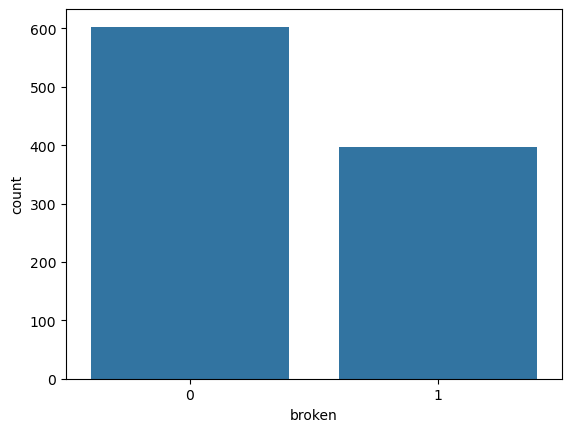

In [82]:
sns.countplot(x=df.broken)

In [83]:
for i in df.columns:
    print(f"{i}, : {df[i].unique()}")

lifetime, : [56 81 60 86 34 30 68 65 23 38 29 82 80 48 92 88 74 61 35 26 63 79 53 73
 13 36 31 25 58 19 84 12 15 43  1 20 16  3 18  7 47 39 57  4 24 28 49 76
 52  8 40 46  5 41 93 77 62 85 55 33 17 45  9 72 50 42 44 54 64 27 22 59
 66 83 14 51 71 21 78  6 69 89  2 67 87 11 10 32 37 90]
broken, : [0 1]
pressureInd, : [ 92.17885406  72.07593772  96.27225443  94.40646126  97.75289859
  87.67880097  94.61417404  96.48330289 105.486158    99.17823531
  97.81784409  67.81225145  86.36611059  76.14465414 103.1072633
  88.41407945  84.35504868  79.66925455  86.22910861  84.17942039
 100.0059233  115.6075596   97.69718903 101.4156229  118.9786971
 102.1127749  129.1243378  109.0330362  107.2980695  127.2639544
 138.1911205   72.55408417  95.21464918  91.24713174  81.55537698
  69.13459519 132.8574784   54.73533145  84.89864628  94.15228726
  84.34406647  95.75352436 123.9284399  101.5053508  120.9455502
  83.06857115 113.3491219   75.64669299 113.4358321   81.77978353
  68.85065142 150.665421  

In [84]:
df.describe(include='all')

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,NaN,NaN,NaN,3,4
top,NaN,NaN,NaN,NaN,NaN,TeamB,Provider2
freq,NaN,NaN,NaN,NaN,NaN,356,266
mean,55.195000,0.397000,98.599338,99.376723,100.628541,NaN,NaN
std,26.472737,0.489521,19.964052,9.988726,19.633060,NaN,NaN
min,1.000000,0.000000,33.481917,58.547301,42.279598,NaN,NaN
25%,34.000000,0.000000,85.558076,92.771764,87.676913,NaN,NaN
50%,60.000000,0.000000,97.216997,99.433959,100.592277,NaN,NaN
75%,80.000000,1.000000,112.253190,106.120762,113.662885,NaN,NaN


In [85]:
df.broken.value_counts()

broken
0    603
1    397
Name: count, dtype: int64

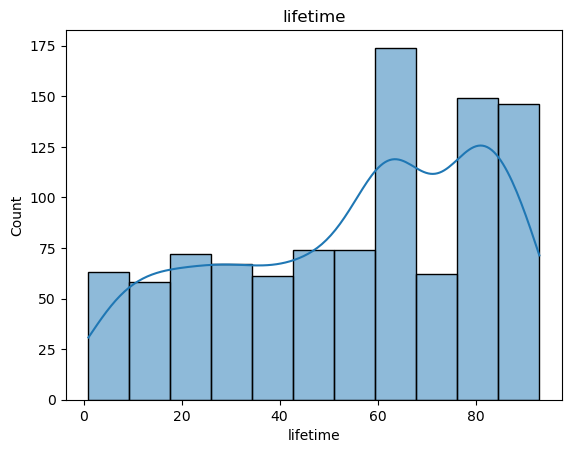

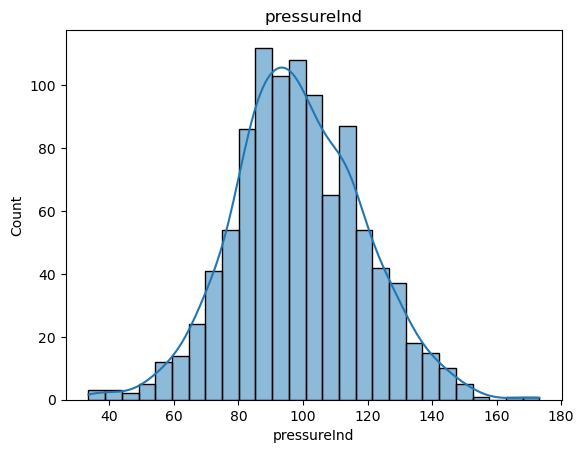

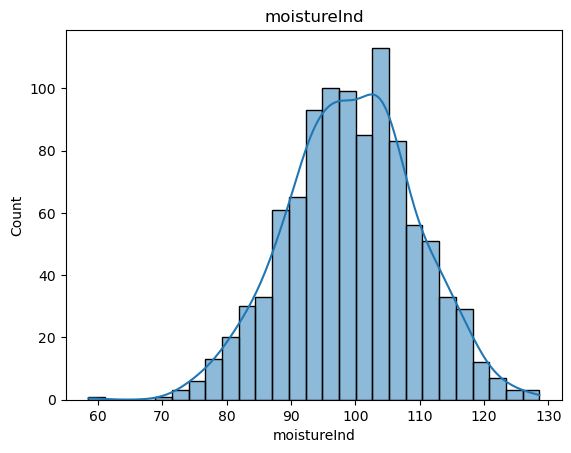

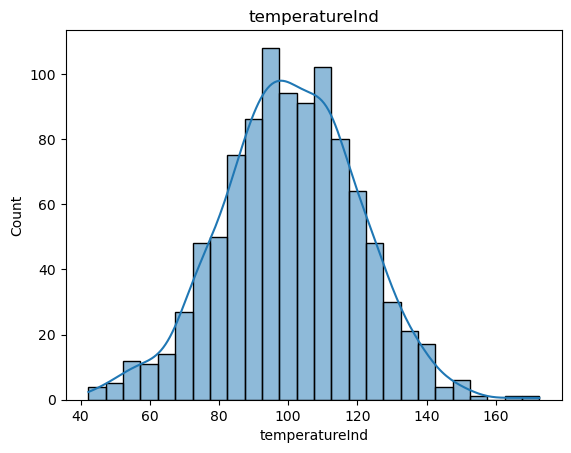

In [86]:
for col in ['lifetime', 'pressureInd', 'moistureInd', 'temperatureInd']:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

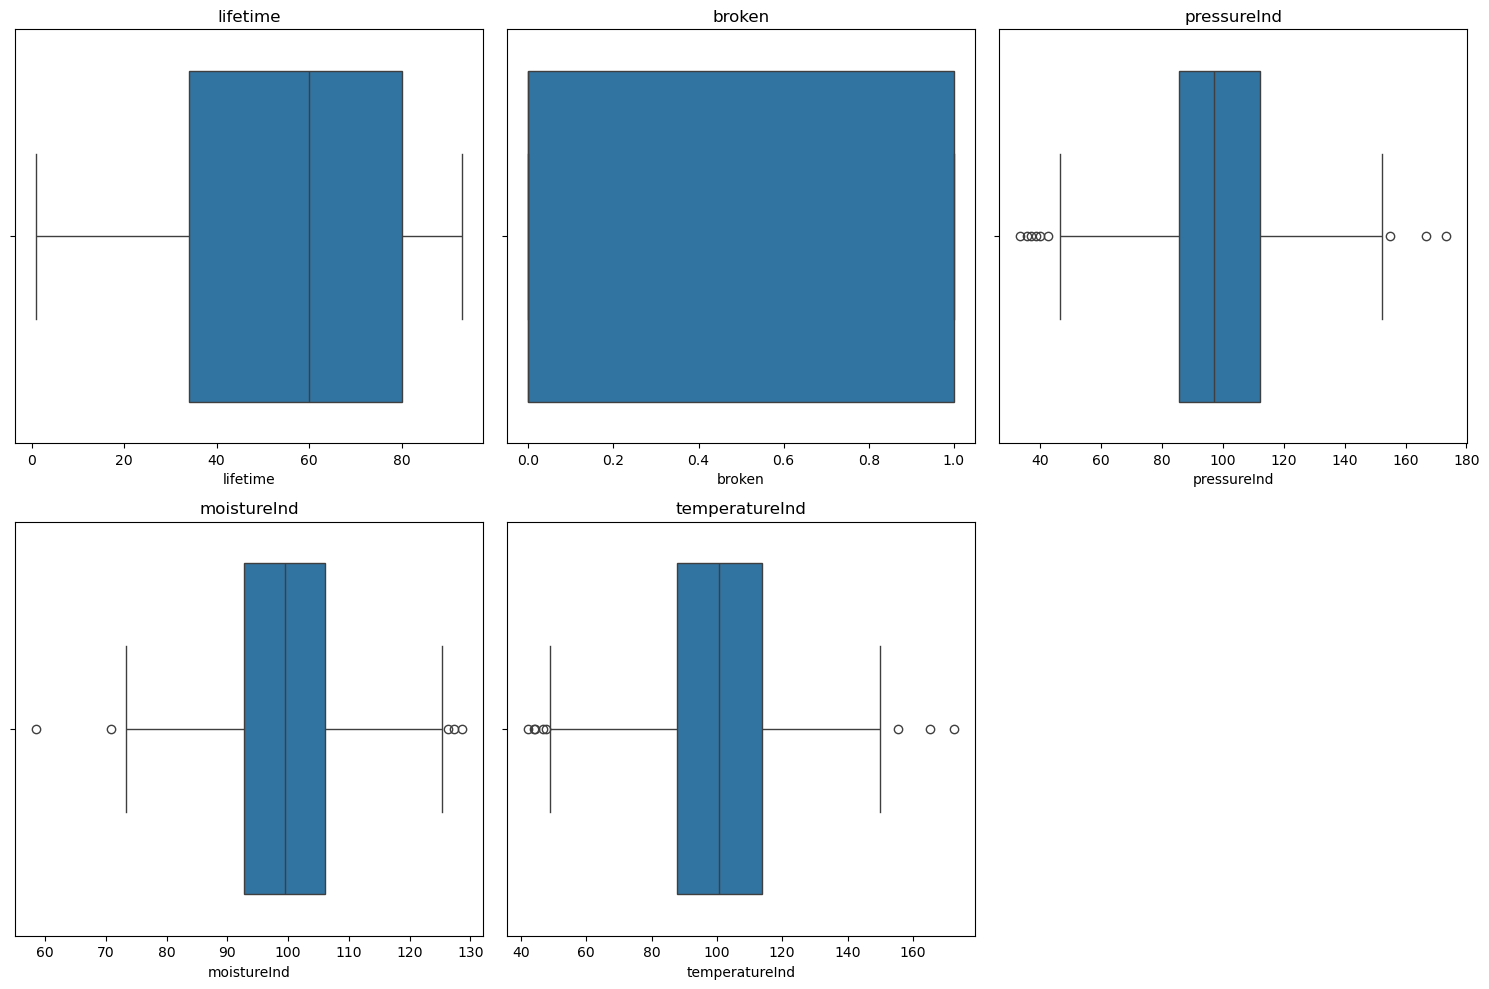

In [87]:
import math
cols = df.select_dtypes(include='number').columns
n = len(cols)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 5*rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

# hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

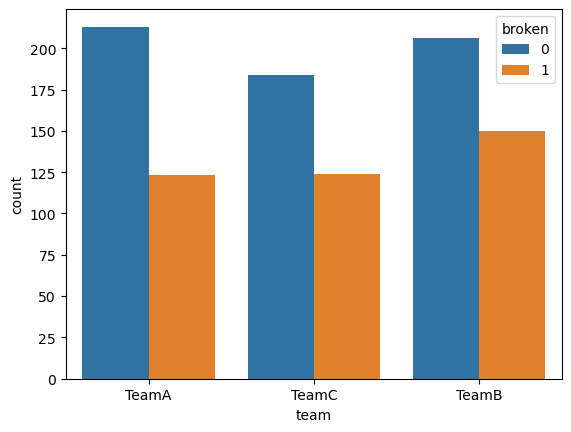

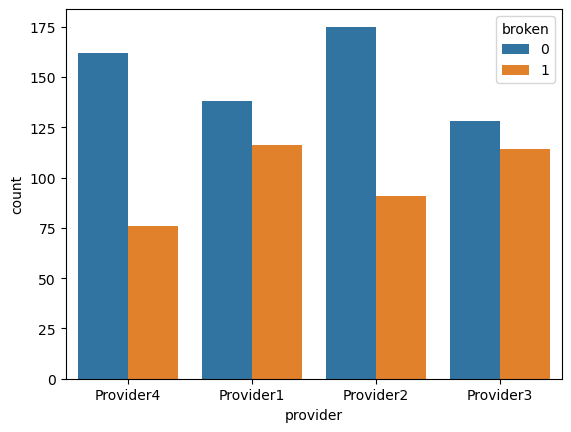

In [88]:
sns.countplot(x=df.team, hue=df.broken)
plt.show()

sns.countplot(x=df.provider, hue=df.broken)
plt.show()

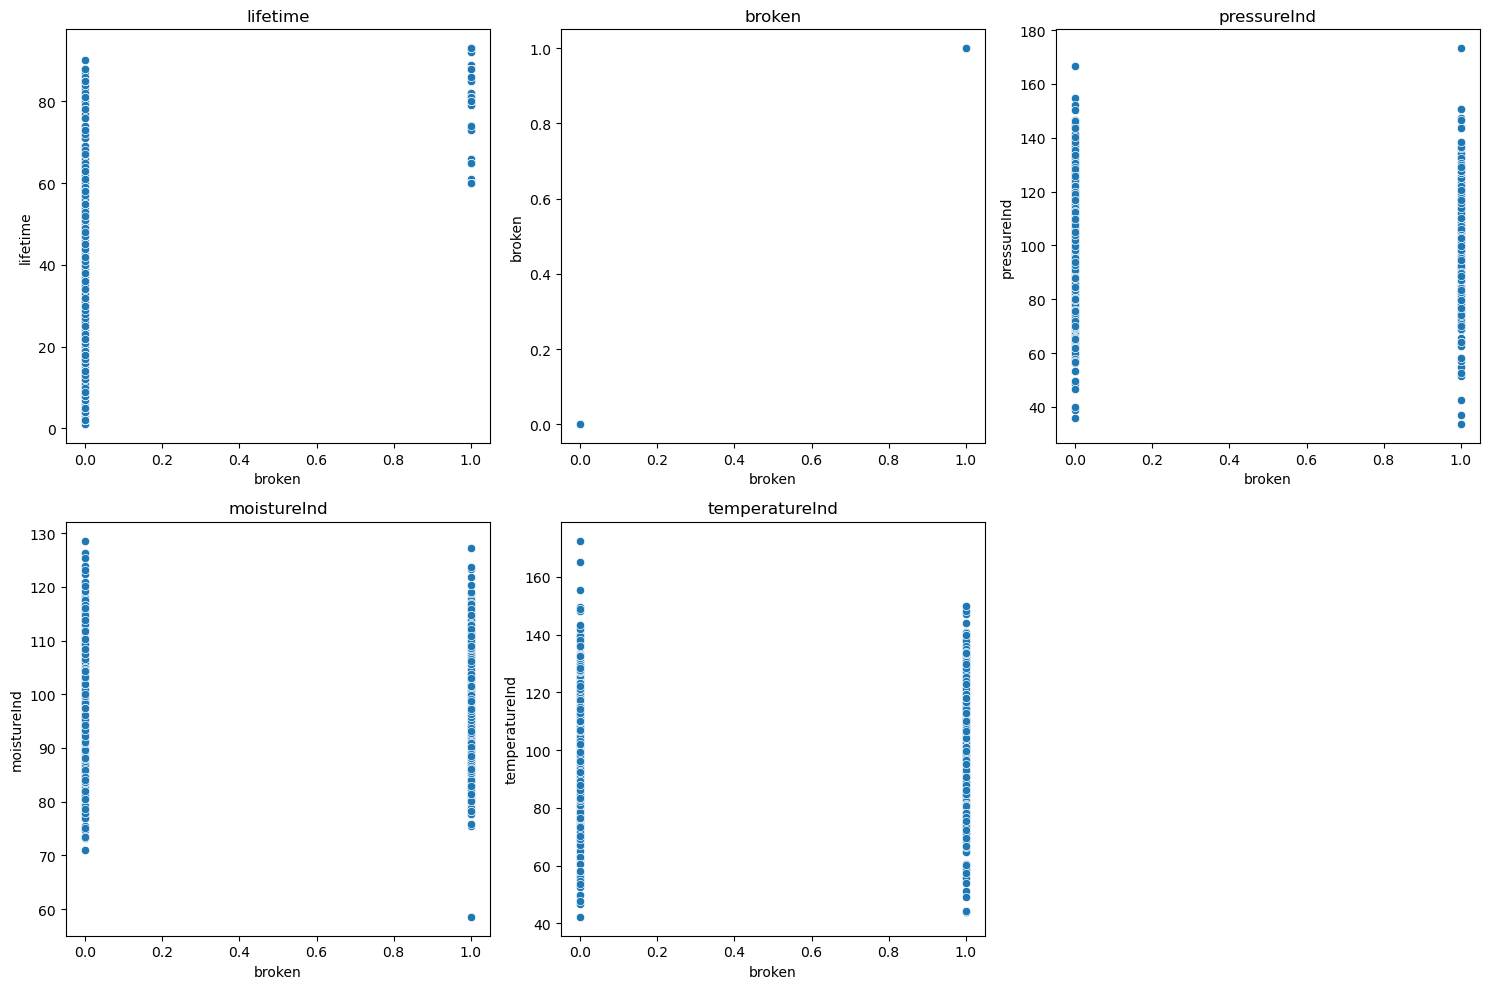

In [89]:
cols = df.select_dtypes(include='number').columns
n = len(cols)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 5*rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.scatterplot(x=df.broken, y=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

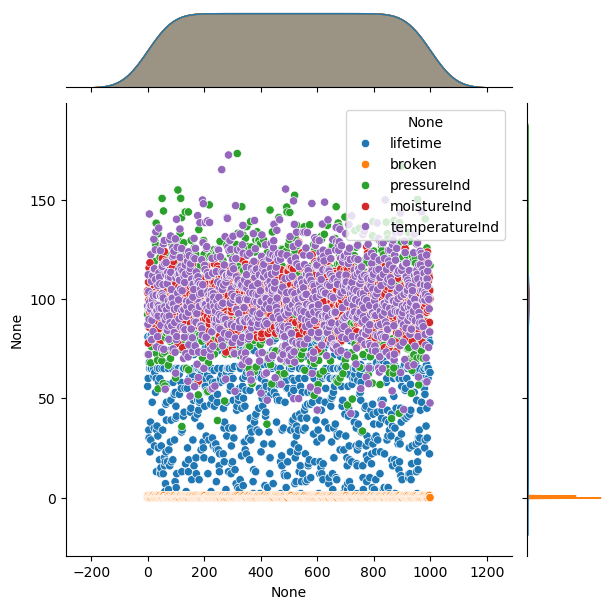

In [90]:
sns.jointplot(data=df)

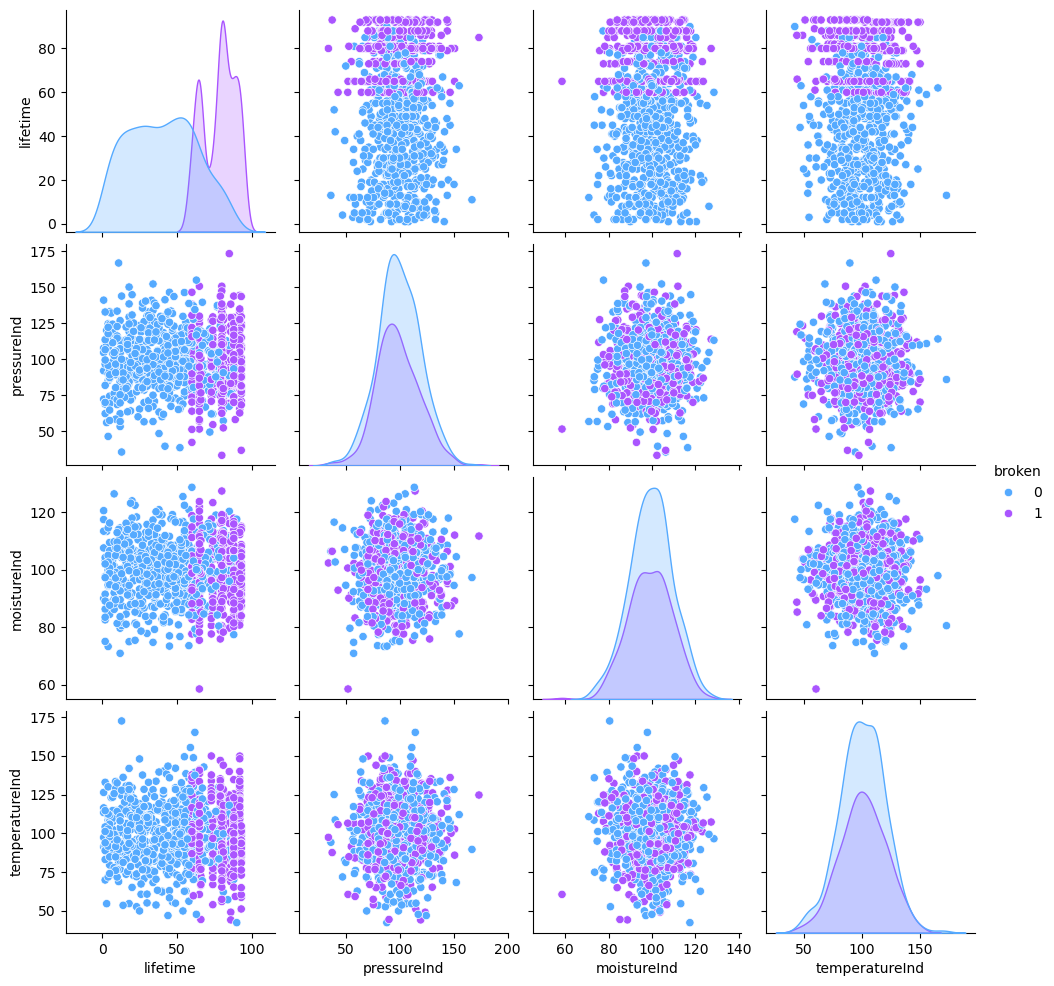

In [91]:
sns.pairplot(df,hue='broken', palette='cool')
plt.show()

<Axes: ylabel='Count'>

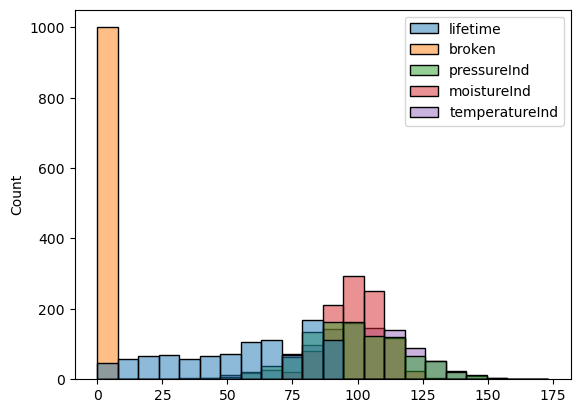

In [92]:
sns.histplot(df)

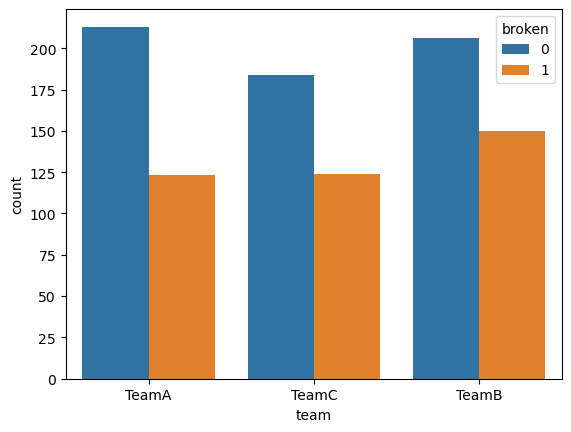

In [93]:
sns.countplot(x=df.team,hue=df.broken)
plt.show()

## Feature and Label creation

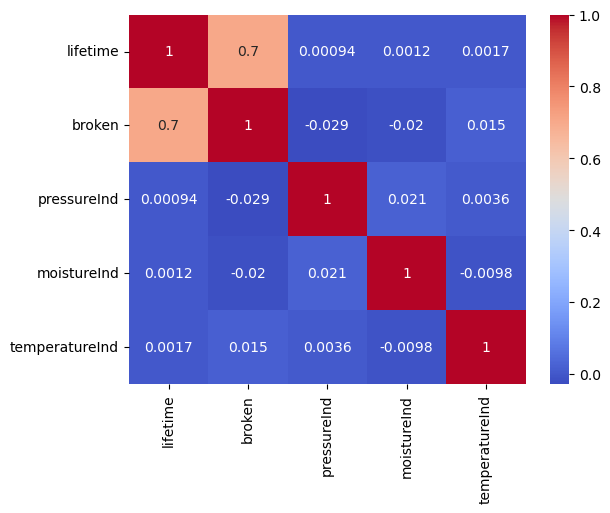

In [94]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()

### Encoding
+ its used to convert string data into numeric value
#### Types of Endoing
  - label Encoding
  - One hot encoding
  - Ordinal Encoding
  - Frequency Encoding
  - dummy Encoding
  - target /mean Encoding

In [95]:
## Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df.team = le.fit_transform(df.team)
df.provider = le.fit_transform(df.provider)

In [96]:
df.team.unique()

array([0, 2, 1])

In [97]:
le.inverse_transform([0,2,1])

array(['Provider1', 'Provider3', 'Provider2'], dtype=object)

In [98]:
df_encoded = pd.get_dummies(df, columns=['team','provider'], drop_first=True)
df_encoded.head()

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team_1,team_2,provider_1,provider_2,provider_3
0,56,0,92.178854,104.230204,96.517159,False,False,False,False,True
1,81,1,72.075938,103.065701,87.271062,False,True,False,False,True
2,60,0,96.272254,77.801376,112.196170,False,False,False,False,False
3,86,1,94.406461,108.493608,72.025374,False,True,True,False,False
4,34,0,97.752899,99.413492,103.756271,True,False,False,False,False


In [99]:
X = df_encoded.drop('broken', axis=1)
y = df_encoded['broken']


### Train Test Split

In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 9)
(200, 9)
(800,)
(200,)


### Standard Scalling

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [102]:
X_train

array([[ 0.66740098,  1.44671146,  0.41538586, ..., -0.62360956,
        -0.56387691, -0.54846423],
       [ 0.17175901,  0.73741898,  2.92296012, ..., -0.62360956,
        -0.56387691, -0.54846423],
       [ 0.43864315, -0.43216136,  1.50389237, ..., -0.62360956,
        -0.56387691,  1.82327297],
       ...,
       [ 0.36239054, -0.22162718,  0.78623891, ..., -0.62360956,
         1.7734367 , -0.54846423],
       [ 0.51489576, -1.60181701, -0.37157483, ...,  1.60356745,
        -0.56387691, -0.54846423],
       [-0.5526408 , -0.31225918, -0.69248684, ...,  1.60356745,
        -0.56387691, -0.54846423]], shape=(800, 9))

### Logistic Regression model

In [103]:
from sklearn.linear_model import LogisticRegression

lg = LogisticRegression()
lg.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Model Prediction

In [104]:
y_pred = lg.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0])

## Model Evaluation for Classification Algorithm

### Confusion Matrix
Used to measure the performance of a classification model by comparing predicted vs actual values.

### Accuracy
Defined as all correct predictions divided by all predictions.

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

### Precision
Defined as the predictions that are actually positive, divided by all predicted positive (yes) cases.

$$Precision = \frac{TP}{TP + FP}$$

### Recall
Defined as the predictions that are actually positive, divided by all actual positive (yes) cases.

$$Recall = \frac{TP}{TP + FN}$$

### F1 Score
The harmonic mean of Precision and Recall, balancing the two into a single metric.

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

In [109]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

ac = accuracy_score(y_test, y_pred)
re = recall_score(y_test, y_pred)
pr = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy Score : ' , ac)
print('recall Score : ' , re)
print('precision Score : ' , pr)
print('f1 Score : ' , f1)

Accuracy Score :  0.96
recall Score :  1.0
precision Score :  0.9090909090909091
f1 Score :  0.9523809523809523


### Confusion matrix

In [113]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
cm

array([[112,   8],
       [  0,  80]])

In [115]:
### Confusion Matrix Display

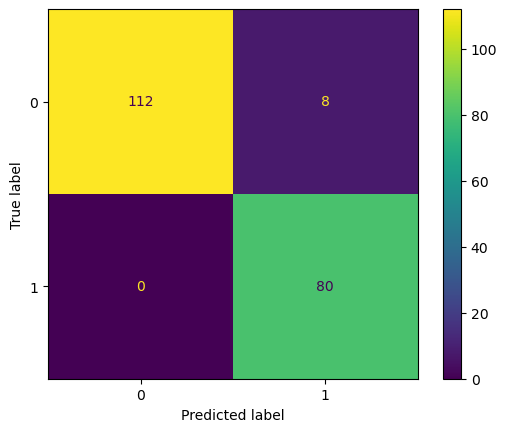

In [114]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()

### Classification Report

In [111]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.93      0.97       120
           1       0.91      1.00      0.95        80

    accuracy                           0.96       200
   macro avg       0.95      0.97      0.96       200
weighted avg       0.96      0.96      0.96       200



In [116]:
df1 = pd.DataFrame({'Y_test' : list(y_test), 'Predicted': y_pred})


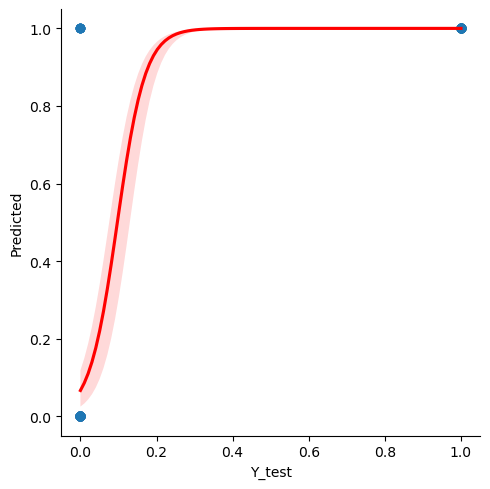

In [121]:
sns.lmplot(x= 'Y_test', y= 'Predicted', data= df1, logistic=True , line_kws={'color' : 'r'})

# KNN

In [122]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [123]:
y_pred1 = knn.predict(X_test)
y_pred1

array([0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0])

### KNN Model Evaluation

In [124]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

ac = accuracy_score(y_test, y_pred1)
re = recall_score(y_test, y_pred1)
pr = precision_score(y_test, y_pred1)
f1 = f1_score(y_test, y_pred1)

print('Accuracy Score : ' , ac)
print('recall Score : ' , re)
print('precision Score : ' , pr)
print('f1 Score : ' , f1)

Accuracy Score :  0.855
recall Score :  0.8625
precision Score :  0.7931034482758621
f1 Score :  0.8263473053892215


In [127]:
cm1 = confusion_matrix(y_test, y_pred1)
cm1

array([[102,  18],
       [ 11,  69]])

### KNN Confusion Matrix Display

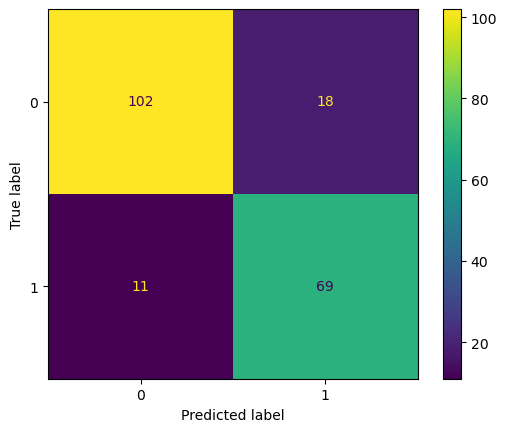

In [128]:
cmd = ConfusionMatrixDisplay(cm1)
cmd.plot()
plt.show()

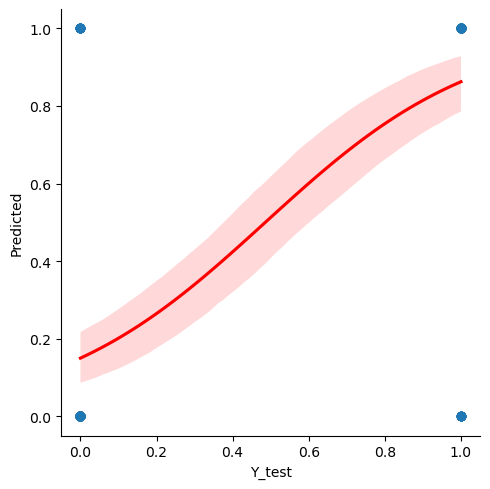

In [136]:
sns.lmplot(x='Y_test', y='Predicted', data=df2, logistic=True, line_kws={'color': 'r'})
plt.show()

## Types of Naive Bayes

### 1. Gaussian Naive Bayes
Used when features are **continuous** and assumed to follow a normal (Gaussian) distribution.
- Example: predicting disease based on age, blood pressure, etc.
```python
from sklearn.naive_bayes import GaussianNB
```

### 2. Multinomial Naive Bayes
Used for **discrete counts**, especially word frequency/count data.
- Example: spam detection, text classification (bag-of-words)
```python
from sklearn.naive_bayes import MultinomialNB
```

### 3. Bernoulli Naive Bayes
Used for **binary/boolean features** (feature present or not, 0 or 1).
- Example: whether a specific word appears in an email or not
```python
from sklearn.naive_bayes import BernoulliNB
```

### Quick Comparison
| Type        | Data Type              | Common Use Case         |
|-------------|-------------------------|---------------------------|
| Gaussian    | Continuous numeric       | Medical, sensor data      |
| Multinomial | Word counts / frequency  | Spam detection, NLP       |
| Bernoulli   | Binary (0/1)             | Word presence/absence     |

### Gussian Naive bayes

In [137]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train , y_train)

,priors,None
,var_smoothing,1e-09


In [143]:
y_pred2 = gnb.predict(X_test)
y_pred2

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0])

In [144]:
ac = accuracy_score(y_test, y_pred2)
re = recall_score(y_test, y_pred2)
pr = precision_score(y_test, y_pred2)
f1 = f1_score(y_test, y_pred2)

print('Accuracy Score : ' , ac)
print('recall Score : ' , re)
print('precision Score : ' , pr)
print('f1 Score : ' , f1)

Accuracy Score :  0.895
recall Score :  0.9625
precision Score :  0.8105263157894737
f1 Score :  0.88


In [145]:
cm2 = confusion_matrix(y_test, y_pred2)
cm2

array([[102,  18],
       [  3,  77]])

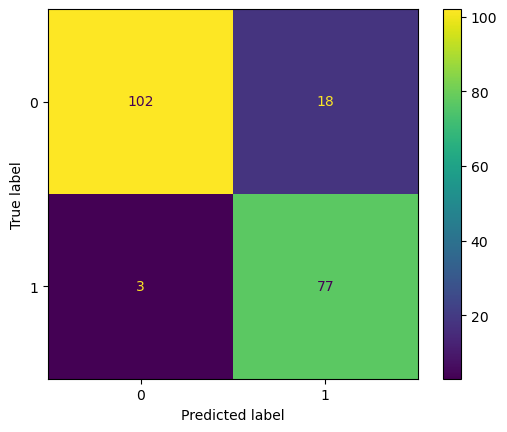

In [142]:
cmd = ConfusionMatrixDisplay(cm2)
cmd.plot()
plt.show()

<pre>
<h2>Support Vector Machine (SVM)</h2>
SVM is a supervised learning algorithm used for classification (and 
regression) that works by finding the **best boundary (hyperplane)** 
that separates classes with the maximum margin.

The main goal of SVM is to create best fit line or Support Vector and decision Boundary that can easily segregate the data in different classes so that we can easily put new data point in the correct class in the future.

</pre>
### Kernel Trick
When data isn't linearly separable, SVM uses a **kernel function** to 
project data into a higher dimension where it becomes separable.
- **Linear kernel** — straight-line boundary
- **RBF (Radial Basis Function)** — curved/non-linear boundary
- **Polynomial kernel** — polynomial-shaped boundary

In [146]:
from sklearn.svm import SVC

svc = SVC(kernel='rbf', gamma=0.03, C=1000)
svc.fit(X_train, y_train)

,C,1000
,kernel,'rbf'
,degree,3
,gamma,0.03
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [153]:
y_pred3 = svc.predict(X_test)
y_pred3

ac = accuracy_score(y_test, y_pred3)
re = recall_score(y_test, y_pred3)
pr = precision_score(y_test, y_pred3)
f1 = f1_score(y_test, y_pred3)

print('Accuracy Score : ' , ac)
print('recall Score : ' , re)
print('precision Score : ' , pr)
print('f1 Score : ' , f1)

Accuracy Score :  0.96
recall Score :  0.9625
precision Score :  0.9390243902439024
f1 Score :  0.9506172839506173


In [154]:
cm3 = confusion_matrix(y_test, y_pred3)
cm3

array([[115,   5],
       [  3,  77]])

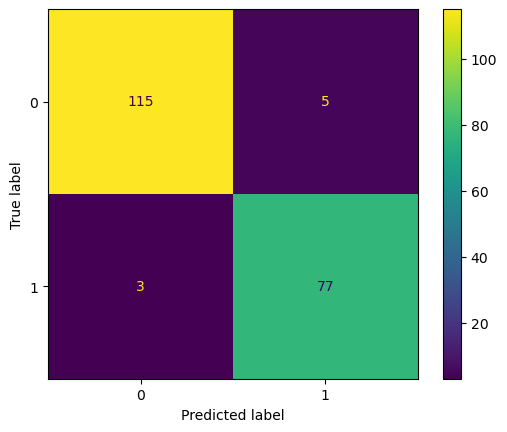

In [155]:
cmd = ConfusionMatrixDisplay(cm3)
cmd.plot()
plt.show()

In [158]:
## NExt class

import nltk

In [ ]:
nltk.download()

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml
